# DIAGNOSTIC: Data Structure & Model Input Analysis
## Deep dive to understand what we're actually predicting and with what features

**Goal**: Understand the fundamental data structure, identify any issues, and verify our modeling approach is valid.

In [17]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Navigate to project root
import os
os.chdir('D:/capstone_pipeline')
print(f"Working directory: {os.getcwd()}")

Working directory: D:\capstone_pipeline


## Part 1: Understand the Source Data Files

In [18]:
# Load response_updated.csv - this is our TARGET source
print("=" * 70)
print("PART 1A: Understanding response_updated.csv (TARGET DATA)")
print("=" * 70)

response_df = pd.read_csv('data/response_updated.csv')

print(f"\nShape: {response_df.shape}")
print(f"\nColumns: {list(response_df.columns)}")
print(f"\nFirst few rows:")
display(response_df.head(10))

print(f"\n\nVt Types (NAME column):")
print(response_df['NAME'].value_counts())

print(f"\n\nNumber of unique wafers: {response_df['WAFER_SCRIBE'].nunique()}")
print(f"Total rows: {len(response_df)}")
print(f"Expected rows if 1 measurement per wafer per Vt type: {response_df['WAFER_SCRIBE'].nunique() * response_df['NAME'].nunique()}")

PART 1A: Understanding response_updated.csv (TARGET DATA)

Shape: (76644, 6)

Columns: ['WAFER_SCRIBE', 'LOT_ID', 'NAME', 'VALUE', 'STDEV', 'PARAM_END_DATETIME']

First few rows:


,WAFER_SCRIBE,LOT_ID,NAME,VALUE,STDEV,PARAM_END_DATETIME
0,WS687836K001,687836K.00K,NFET1_VT,0.890625,0.125000,2021-10-13T12:29:27
1,WS687836K001,687836K.00K,PFET2_VT,0.754386,0.105263,2021-10-13T12:29:27
2,WS687836K001,687836K.00K,NFET2_VT,0.770270,0.229730,2021-10-13T12:29:27
3,WS687836K001,687836K.00K,PFET1_VT,0.719298,0.114035,2021-10-13T12:29:27
4,WS687836K002,687836K.00K,NFET2_VT,0.797297,0.202703,2021-10-13T12:34:49
5,WS687836K002,687836K.00K,NFET1_VT,0.921875,0.109375,2021-10-13T12:34:49
6,WS687836K002,687836K.00K,PFET2_VT,0.491228,0.157895,2021-10-13T12:34:49
7,WS687836K002,687836K.00K,PFET1_VT,0.552632,0.114035,2021-10-13T12:34:49
8,WS687836K003,687836K.00K,PFET1_VT,0.491228,0.114035,2021-10-13T12:40:09
9,WS687836K003,687836K.00K,NFET1_VT,0.687500,0.171875,2021-10-13T12:40:09




Vt Types (NAME column):
NAME
NFET1_VT    17202
PFET2_VT    17202
NFET2_VT    17202
PFET1_VT    17202
PFET3_VT     3918
NFET3_VT     3918
Name: count, dtype: int64


Number of unique wafers: 16817
Total rows: 76644
Expected rows if 1 measurement per wafer per Vt type: 100902


In [19]:
# Check for duplicates in response data
print("\n" + "=" * 70)
print("PART 1B: Checking for duplicate measurements")
print("=" * 70)

# For NFET1_VT specifically
nfet1 = response_df[response_df['NAME'] == 'NFET1_VT']
print(f"\nNFET1_VT:")
print(f"  Total rows: {len(nfet1)}")
print(f"  Unique wafers: {nfet1['WAFER_SCRIBE'].nunique()}")
print(f"  Duplicate measurements: {len(nfet1) - nfet1['WAFER_SCRIBE'].nunique()}")

# Show some duplicate examples
if len(nfet1) > nfet1['WAFER_SCRIBE'].nunique():
    duplicated_wafers = nfet1[nfet1.duplicated(subset='WAFER_SCRIBE', keep=False)].sort_values('WAFER_SCRIBE')
    print(f"\n  Example duplicates (first 10):")
    display(duplicated_wafers.head(10))
    
    # Check variance in duplicate values
    dup_wafer_example = duplicated_wafers['WAFER_SCRIBE'].iloc[0]
    dup_values = nfet1[nfet1['WAFER_SCRIBE'] == dup_wafer_example]['VALUE'].values
    print(f"\n  Example duplicate wafer '{dup_wafer_example}':")
    print(f"    Values: {dup_values}")
    print(f"    Difference: {dup_values.max() - dup_values.min():.6f}")


PART 1B: Checking for duplicate measurements

NFET1_VT:
  Total rows: 17202
  Unique wafers: 16817
  Duplicate measurements: 385

  Example duplicates (first 10):


,WAFER_SCRIBE,LOT_ID,NAME,VALUE,STDEV,PARAM_END_DATETIME
233,WS688144K003,688144K.00K,NFET1_VT,1.312500,0.093750,2021-10-04T13:54:34
236,WS688144K003,688144K.00K,NFET1_VT,1.312500,0.093750,2021-10-04T13:54:34
237,WS688144K003,688144K.00K,NFET1_VT,1.265625,0.062500,2021-10-04T19:38:59
251,WS688144K006,688144K.00K,NFET1_VT,1.406250,0.078125,2021-10-04T14:39:14
252,WS688144K006,688144K.00K,NFET1_VT,1.406250,0.078125,2021-10-04T14:39:14
255,WS688144K006,688144K.00K,NFET1_VT,1.437500,0.062500,2021-10-04T19:45:05
295,WS688144K014,688144K.00K,NFET1_VT,1.562500,0.125000,2021-10-04T19:50:20
297,WS688144K014,688144K.00K,NFET1_VT,1.593750,0.078125,2021-10-04T16:18:56
303,WS688144K015,688144K.00K,NFET1_VT,1.500000,0.093750,2021-10-04T16:53:14
309,WS688144K015,688144K.00K,NFET1_VT,1.484375,0.093750,2021-10-04T19:55:46



  Example duplicate wafer 'WS688144K003':
    Values: [1.31250019 1.31250019 1.26562532]
    Difference: 0.046875



PART 1C: TARGET VALUE Distribution (NFET1_VT)

Statistics:
count    17202.000000
mean         0.497047
std          0.168481
min         -0.750000
25%          0.406250
50%          0.500000
75%          0.593750
max          1.593750
Name: VALUE, dtype: float64


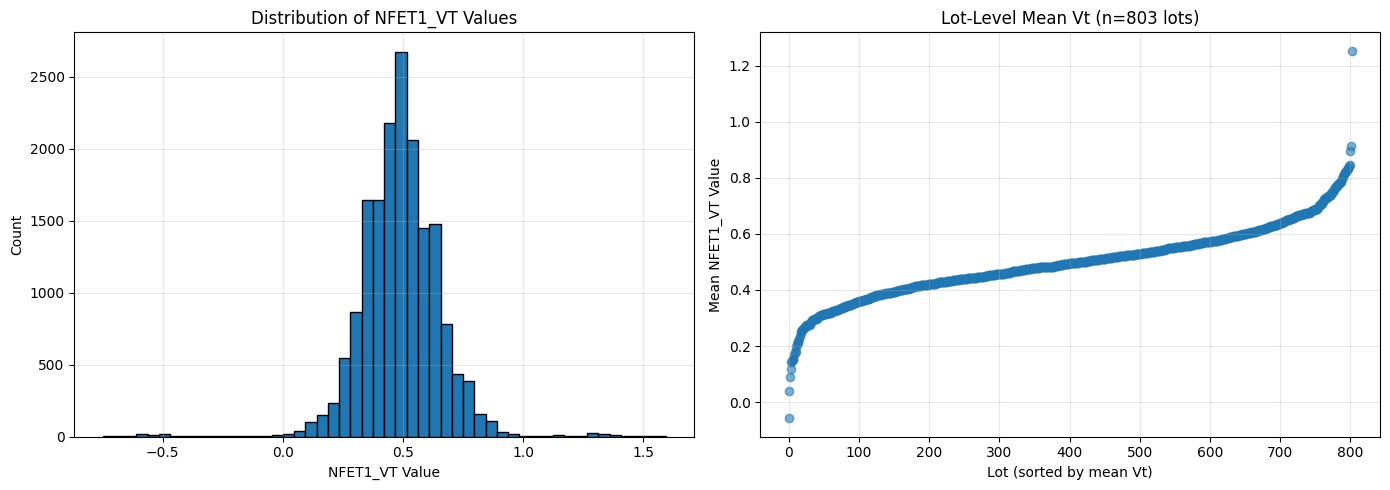


Lot-level variance:
  Between-lot std: 0.130455
  Within-lot avg std: 0.071705
  Total std: 0.168481


In [20]:
# Understand the VALUE distribution
print("\n" + "=" * 70)
print("PART 1C: TARGET VALUE Distribution (NFET1_VT)")
print("=" * 70)

print(f"\nStatistics:")
print(nfet1['VALUE'].describe())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(nfet1['VALUE'], bins=50, edgecolor='black')
axes[0].set_xlabel('NFET1_VT Value')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of NFET1_VT Values')
axes[0].grid(True, alpha=0.3)

# By lot
lot_means = nfet1.groupby('LOT_ID')['VALUE'].mean().sort_values()
axes[1].scatter(range(len(lot_means)), lot_means, alpha=0.6)
axes[1].set_xlabel('Lot (sorted by mean Vt)')
axes[1].set_ylabel('Mean NFET1_VT Value')
axes[1].set_title(f'Lot-Level Mean Vt (n={len(lot_means)} lots)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLot-level variance:")
print(f"  Between-lot std: {lot_means.std():.6f}")
print(f"  Within-lot avg std: {nfet1.groupby('LOT_ID')['VALUE'].std().mean():.6f}")
print(f"  Total std: {nfet1['VALUE'].std():.6f}")

## Part 2: Understand the Feature Matrices

In [21]:
print("\n" + "=" * 70)
print("PART 2A: Understanding train.parquet (FEATURE MATRIX)")
print("=" * 70)

train_df = pd.read_parquet('outputs/features/train.parquet')
val_df = pd.read_parquet('outputs/features/val.parquet')

print(f"\nTrain shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")

print(f"\nColumns in train.parquet:")
print(f"  Total columns: {len(train_df.columns)}")

# Categorize columns
metadata_cols = [c for c in train_df.columns if c in ['WAFER_SCRIBE', 'LOT_ID', 'PARAM_END_DATETIME', 'is_outlier']]
sensor_mean_cols = [c for c in train_df.columns if '__MEAN' in c and '__SPC_' not in c]
sensor_std_cols = [c for c in train_df.columns if '__STD' in c and '__SPC_' not in c]
spc_cols = [c for c in train_df.columns if '__SPC_' in c]
missing_cols = [c for c in train_df.columns if '__MISSING' in c]
equip_cols = [c for c in train_df.columns if '__EQUIP' in c]
position_cols = [c for c in train_df.columns if '__POSITION' in c]
lot_feature_cols = [c for c in train_df.columns if c.startswith('lot_') or c.startswith('first_') or c.startswith('last_') or c == 'step_coverage']

print(f"\n  Metadata: {len(metadata_cols)}")
print(f"  Sensor MEAN features: {len(sensor_mean_cols)}")
print(f"  Sensor STD features: {len(sensor_std_cols)}")
print(f"  SPC features: {len(spc_cols)}")
print(f"  Missing indicators: {len(missing_cols)}")
print(f"  Equipment columns: {len(equip_cols)}")
print(f"  Position columns: {len(position_cols)}")
print(f"  Lot-level features: {len(lot_feature_cols)}")

print(f"\nMetadata columns: {metadata_cols}")
print(f"\nLot feature columns: {lot_feature_cols}")

print(f"\n\nFirst few sensor MEAN columns:")
print(sensor_mean_cols[:10])


PART 2A: Understanding train.parquet (FEATURE MATRIX)

Train shape: (13510, 10306)
Val shape: (3307, 10306)

Columns in train.parquet:
  Total columns: 10306

  Metadata: 4
  Sensor MEAN features: 8402
  Sensor STD features: 1486
  SPC features: 361
  Missing indicators: 3133
  Equipment columns: 0
  Position columns: 46
  Lot-level features: 6

Metadata columns: ['WAFER_SCRIBE', 'LOT_ID', 'PARAM_END_DATETIME', 'is_outlier']

Lot feature columns: ['lot_position', 'lot_size', 'lot_position_normalized', 'step_coverage', 'first_step', 'last_step']


First few sensor MEAN columns:
['APCPressure__WP0008__MEAN', 'AirbagPressureArea4__CM0003__MEAN', 'AsH3GasBottlePressure__IM0014__MEAN', 'B5_BRANCH_VV_ActualTemp__DF0022__MEAN', 'BiasMatchSeriesCapPosition__DE0005__MEAN', 'ChamberPressure__DF0007__MEAN', 'ChuckHeGasPressureInner__DE0012__MEAN', 'CupHumidity__PH0017__MEAN', 'DrainResistivity__WP0068__MEAN', 'ESCBasePlateBiasVoltage__DE0012__MEAN']


In [22]:
print("\n" + "=" * 70)
print("PART 2B: Understanding Wafer Coverage")
print("=" * 70)

print(f"\nUnique wafers in train: {train_df['WAFER_SCRIBE'].nunique()}")
print(f"Unique wafers in val: {val_df['WAFER_SCRIBE'].nunique()}")
print(f"Total unique wafers in features: {train_df['WAFER_SCRIBE'].nunique() + val_df['WAFER_SCRIBE'].nunique()}")

print(f"\nUnique wafers in response (NFET1_VT): {nfet1['WAFER_SCRIBE'].nunique()}")

# Check overlap
train_wafers = set(train_df['WAFER_SCRIBE'])
val_wafers = set(val_df['WAFER_SCRIBE'])
nfet1_wafers = set(nfet1['WAFER_SCRIBE'])

print(f"\nOverlap analysis:")
print(f"  Train wafers with NFET1_VT: {len(train_wafers & nfet1_wafers)}")
print(f"  Val wafers with NFET1_VT: {len(val_wafers & nfet1_wafers)}")
print(f"  Train wafers WITHOUT NFET1_VT: {len(train_wafers - nfet1_wafers)}")
print(f"  Val wafers WITHOUT NFET1_VT: {len(val_wafers - nfet1_wafers)}")


PART 2B: Understanding Wafer Coverage

Unique wafers in train: 13510
Unique wafers in val: 3307
Total unique wafers in features: 16817

Unique wafers in response (NFET1_VT): 16817

Overlap analysis:
  Train wafers with NFET1_VT: 13510
  Val wafers with NFET1_VT: 3307
  Train wafers WITHOUT NFET1_VT: 0
  Val wafers WITHOUT NFET1_VT: 0


In [23]:
print("\n" + "=" * 70)
print("PART 2C: Understanding LOT Structure")
print("=" * 70)

print(f"\nUnique lots in train: {train_df['LOT_ID'].nunique()}")
print(f"Unique lots in val: {val_df['LOT_ID'].nunique()}")

# Check if lots are split across train/val
train_lots = set(train_df['LOT_ID'])
val_lots = set(val_df['LOT_ID'])
overlap_lots = train_lots & val_lots

print(f"\nLots appearing in BOTH train and val: {len(overlap_lots)}")
if len(overlap_lots) > 0:
    print(f"  WARNING: Lots are split across train/val! This is DATA LEAKAGE.")
    print(f"  Example overlapping lots: {list(overlap_lots)[:5]}")
else:
    print(f"  GOOD: No lot overlap between train/val.")

# Check lot sizes
train_lot_sizes = train_df.groupby('LOT_ID').size()
val_lot_sizes = val_df.groupby('LOT_ID').size()

print(f"\nLot sizes (train):")
print(train_lot_sizes.describe())
print(f"\nLot sizes (val):")
print(val_lot_sizes.describe())


PART 2C: Understanding LOT Structure

Unique lots in train: 640
Unique lots in val: 161

Lots appearing in BOTH train and val: 0
  GOOD: No lot overlap between train/val.

Lot sizes (train):
count    640.000000
mean      21.109375
std        5.244618
min        1.000000
25%       20.000000
50%       24.000000
75%       24.000000
max       25.000000
dtype: float64

Lot sizes (val):
count    161.000000
mean      20.540373
std        5.706349
min        2.000000
25%       20.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64


## Part 3: Understand the Feature-to-Step Mapping


PART 3A: Understanding column_step_map.json

Total features in step map: 10302
SeqNo range: 0 to 240

Features per SeqNo (sample):
0      53
1      74
2     128
3      57
4      89
5     128
6     102
7      42
8      53
9      23
10     37
11     53
12     47
13     65
14     10
15     26
16    168
17     47
18     40
19    102
Name: count, dtype: int64

Cumulative feature availability:
  At SeqNo 24: 1766 features
  At SeqNo 120: 7712 features
  At SeqNo 240: 10302 features


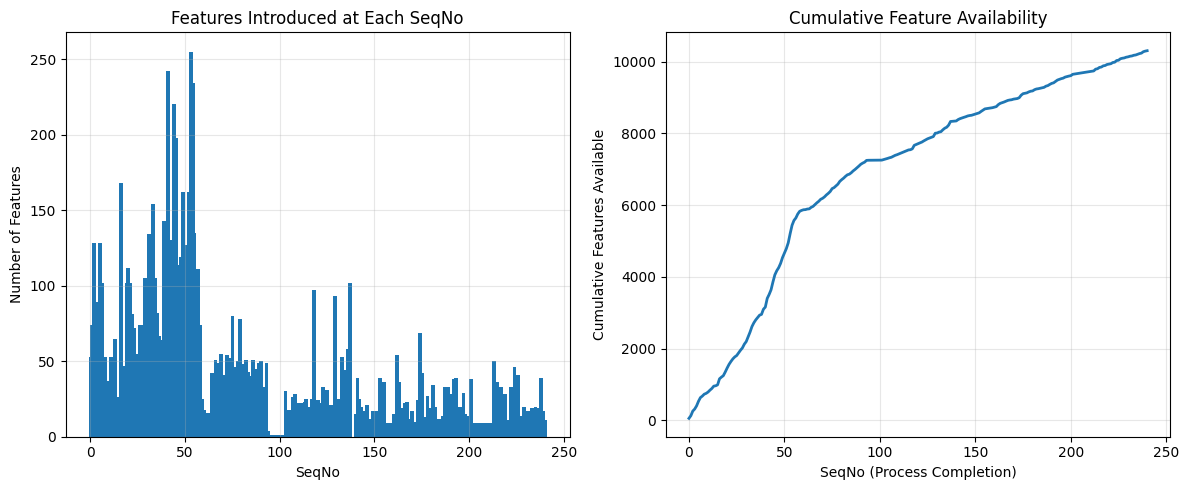

In [24]:
print("\n" + "=" * 70)
print("PART 3A: Understanding column_step_map.json")
print("=" * 70)

with open('outputs/features/column_step_map.json', 'r') as f:
    column_step_map = json.load(f)

print(f"\nTotal features in step map: {len(column_step_map)}")
print(f"SeqNo range: {min(column_step_map.values())} to {max(column_step_map.values())}")

# Distribution of features across SeqNo
seqno_counts = pd.Series(column_step_map.values()).value_counts().sort_index()
print(f"\nFeatures per SeqNo (sample):")
print(seqno_counts.head(20))

# Cumulative feature availability
cumulative_features = seqno_counts.sort_index().cumsum()
print(f"\nCumulative feature availability:")
print(f"  At SeqNo 24: {cumulative_features[24]} features")
print(f"  At SeqNo 120: {cumulative_features[120]} features")
print(f"  At SeqNo 240: {cumulative_features[240]} features")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(seqno_counts.index, seqno_counts.values, width=2)
plt.xlabel('SeqNo')
plt.ylabel('Number of Features')
plt.title('Features Introduced at Each SeqNo')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cumulative_features.index, cumulative_features.values, linewidth=2)
plt.xlabel('SeqNo (Process Completion)')
plt.ylabel('Cumulative Features Available')
plt.title('Cumulative Feature Availability')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Check if all features in train.parquet have a SeqNo mapping
print("\n" + "=" * 70)
print("PART 3B: Checking Feature Coverage in Step Map")
print("=" * 70)

train_feature_cols = [c for c in train_df.columns if c not in metadata_cols]
print(f"\nFeatures in train.parquet: {len(train_feature_cols)}")
print(f"Features in column_step_map: {len(column_step_map)}")

# Features in train but not in step map
missing_from_map = set(train_feature_cols) - set(column_step_map.keys())
print(f"\nFeatures in train.parquet but NOT in step map: {len(missing_from_map)}")
if len(missing_from_map) > 0:
    print(f"  Examples: {list(missing_from_map)[:10]}")
    print(f"  WARNING: These features won't be used in multi-horizon training!")

# Features in step map but not in train
missing_from_train = set(column_step_map.keys()) - set(train_feature_cols)
print(f"\nFeatures in step map but NOT in train.parquet: {len(missing_from_train)}")
if len(missing_from_train) > 0:
    print(f"  Examples: {list(missing_from_train)[:10]}")


PART 3B: Checking Feature Coverage in Step Map

Features in train.parquet: 10302
Features in column_step_map: 10302

Features in train.parquet but NOT in step map: 0

Features in step map but NOT in train.parquet: 0


## Part 4: Understand the Actual Model Input/Output

In [26]:
print("\n" + "=" * 70)
print("PART 4A: What the Model Actually Sees (Horizon 240)")
print("=" * 70)

# Simulate what happens when we merge target with features
# Use the same deduplication logic from notebook 10
vt_filtered = response_df[response_df['NAME'] == 'NFET1_VT'][['WAFER_SCRIBE', 'LOT_ID', 'VALUE']].copy()
vt_filtered = vt_filtered.groupby(['WAFER_SCRIBE', 'LOT_ID'], as_index=False)['VALUE'].mean()
vt_df = vt_filtered.rename(columns={'VALUE': 'vt_value'})

# Merge with train
train_with_target = train_df.merge(vt_df[['WAFER_SCRIBE', 'vt_value']], on='WAFER_SCRIBE', how='left')
val_with_target = val_df.merge(vt_df[['WAFER_SCRIBE', 'vt_value']], on='WAFER_SCRIBE', how='left')

print(f"\nTrain after merge:")
print(f"  Shape: {train_with_target.shape}")
print(f"  Non-null targets: {train_with_target['vt_value'].notna().sum()}")
print(f"  Null targets: {train_with_target['vt_value'].isna().sum()}")

print(f"\nVal after merge:")
print(f"  Shape: {val_with_target.shape}")
print(f"  Non-null targets: {val_with_target['vt_value'].notna().sum()}")
print(f"  Null targets: {val_with_target['vt_value'].isna().sum()}")

# Drop nulls (as done in training)
train_clean = train_with_target.dropna(subset=['vt_value'])
val_clean = val_with_target.dropna(subset=['vt_value'])

print(f"\nAfter dropping null targets:")
print(f"  Train: {len(train_clean)} samples")
print(f"  Val: {len(val_clean)} samples")

# Check target distribution in actual training data
print(f"\nTarget (vt_value) statistics in training data:")
print(train_clean['vt_value'].describe())


PART 4A: What the Model Actually Sees (Horizon 240)

Train after merge:
  Shape: (13514, 10307)
  Non-null targets: 13514
  Null targets: 0

Val after merge:
  Shape: (3307, 10307)
  Non-null targets: 3307
  Null targets: 0

After dropping null targets:
  Train: 13514 samples
  Val: 3307 samples

Target (vt_value) statistics in training data:
count    13514.000000
mean         0.505086
std          0.158493
min         -0.710937
25%          0.406250
50%          0.500000
75%          0.593750
max          1.578125
Name: vt_value, dtype: float64


In [27]:
print("\n" + "=" * 70)
print("PART 4B: Feature Availability at Horizon 240")
print("=" * 70)

# Features available at final horizon
horizon_240_features = [col for col in train_feature_cols if col in column_step_map and column_step_map[col] <= 240]

print(f"\nFeatures available at horizon 240: {len(horizon_240_features)}")
print(f"Total features in train: {len(train_feature_cols)}")
print(f"Features excluded (SeqNo > 240 or not in map): {len(train_feature_cols) - len(horizon_240_features)}")

# Check data completeness
X_train_240 = train_clean[horizon_240_features]
X_val_240 = val_clean[horizon_240_features]

print(f"\nData shape:")
print(f"  X_train: {X_train_240.shape}")
print(f"  X_val: {X_val_240.shape}")

# Check for missing values
train_missing = X_train_240.isna().sum().sum()
val_missing = X_val_240.isna().sum().sum()
print(f"\nMissing values:")
print(f"  Train: {train_missing} ({100*train_missing/X_train_240.size:.2f}%)")
print(f"  Val: {val_missing} ({100*val_missing/X_val_240.size:.2f}%)")

# Check for infinite values
train_inf = np.isinf(X_train_240.select_dtypes(include=[np.number])).sum().sum()
val_inf = np.isinf(X_val_240.select_dtypes(include=[np.number])).sum().sum()
print(f"\nInfinite values:")
print(f"  Train: {train_inf}")
print(f"  Val: {val_inf}")


PART 4B: Feature Availability at Horizon 240

Features available at horizon 240: 10302
Total features in train: 10302
Features excluded (SeqNo > 240 or not in map): 0

Data shape:
  X_train: (13514, 10302)
  X_val: (3307, 10302)

Missing values:
  Train: 513459 (0.37%)
  Val: 126266 (0.37%)

Infinite values:
  Train: 0
  Val: 0


## Part 5: Feature-Target Correlation Analysis


PART 5: Feature-Target Correlation

Numeric features: 10261 / 10302

Computing correlations (this may take a minute)...


d:\capstone_pipeline\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\capstone_pipeline\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 20 features by absolute correlation with target:
HolderWaterFlow__PV0002__MEAN                   0.190525
ChuckHeGasFlow__DE0007__MEAN                    0.179177
O2GeneratorOutput__DF0019__MEAN                 0.173571
HeaterWaterFlowFS106__DF0001__MEAN__MISSING     0.171843
CoolingWaterPressure__DF0001__MEAN__MISSING     0.171843
MainWaterFlowFS101__DF0001__MEAN__MISSING       0.171843
RotatorWaterFlowFS111__DF0001__MEAN__MISSING    0.171843
RHCWaterFlowFS105__DF0001__MEAN__MISSING        0.171843
ShutterWaterFlowFS104__DF0001__MEAN__MISSING    0.171843
FlangeWaterFlowFS102__DF0001__MEAN__MISSING     0.171843
UniformCurrent__IM0013__MEAN                    0.171155
LTO520GasFlowGG1__DF0019__STD                   0.170628
ImplantMapCurrent__IM0013__MEAN                 0.169186
SharedPressure__DF0005__MEAN                    0.167685
_LcfPutX_mm__DE0001__MEAN__MISSING              0.166612
_LcfPutY_mm__DE0001__MEAN__MISSING              0.166612
_LcfGetX_mm__DE0001__MEAN__MISSING

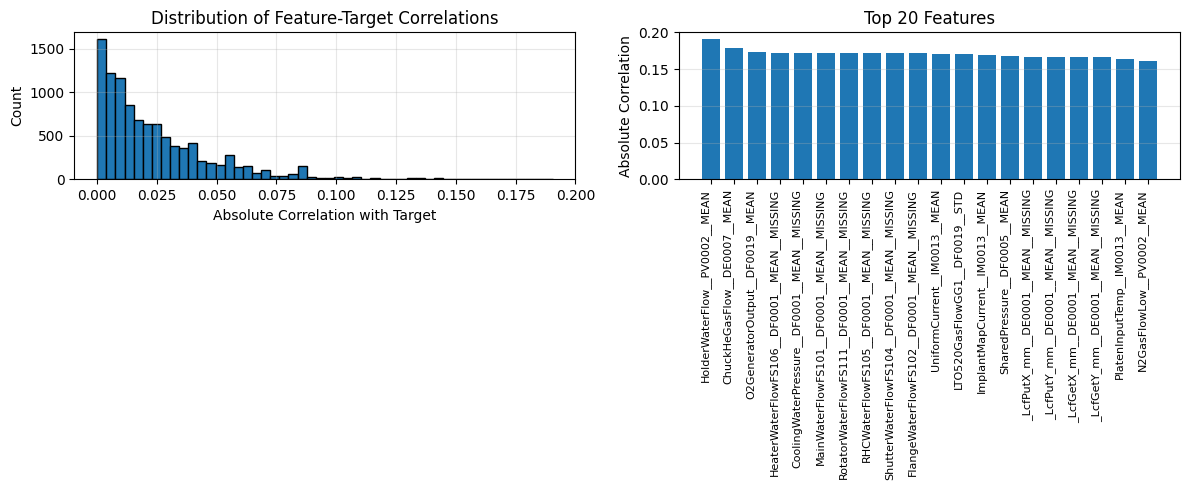


Features with correlation > 0.1: 172
Features with correlation > 0.2: 0
Features with correlation > 0.3: 0


In [28]:
print("\n" + "=" * 70)
print("PART 5: Feature-Target Correlation")
print("=" * 70)

# Compute correlations with target
y_train = train_clean['vt_value']

# Select only numeric features for correlation
numeric_features = X_train_240.select_dtypes(include=[np.number]).columns
print(f"\nNumeric features: {len(numeric_features)} / {len(horizon_240_features)}")

# Compute correlations
print("\nComputing correlations (this may take a minute)...")
correlations = X_train_240[numeric_features].corrwith(y_train).abs().sort_values(ascending=False)

print(f"\nTop 20 features by absolute correlation with target:")
print(correlations.head(20))

print(f"\nCorrelation statistics:")
print(correlations.describe())

# Plot correlation distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(correlations.dropna(), bins=50, edgecolor='black')
plt.xlabel('Absolute Correlation with Target')
plt.ylabel('Count')
plt.title('Distribution of Feature-Target Correlations')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(20), correlations.head(20).values)
plt.xticks(range(20), correlations.head(20).index, rotation=90, ha='right', fontsize=8)
plt.ylabel('Absolute Correlation')
plt.title('Top 20 Features')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nFeatures with correlation > 0.1: {(correlations > 0.1).sum()}")
print(f"Features with correlation > 0.2: {(correlations > 0.2).sum()}")
print(f"Features with correlation > 0.3: {(correlations > 0.3).sum()}")

## Part 6: Check for Data Leakage Issues


PART 6A: Temporal Split Analysis

Train date range:
  Min: 2021-09-19 00:02:47
  Max: 2021-10-15 06:45:20

Val date range:
  Min: 2021-10-15 03:53:13
  Max: 2021-10-19 23:59:11

  Latest train date (2021-10-15 06:45:20) is after earliest val date (2021-10-15 03:53:13)
  Val samples with date before train max: 60 (1.8%)


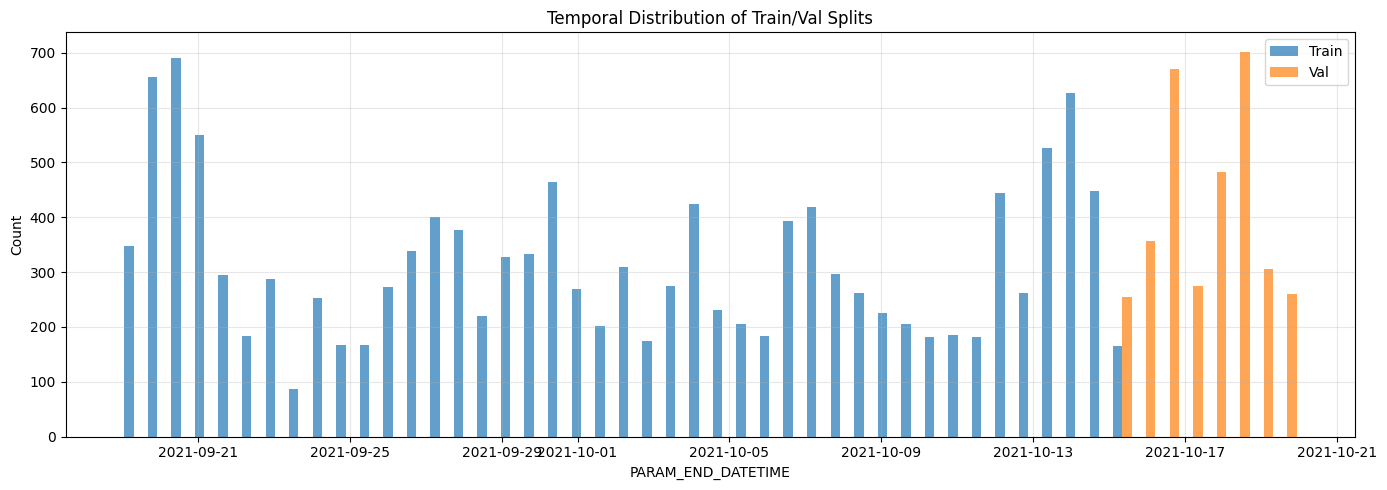

In [29]:
print("\n" + "=" * 70)
print("PART 6A: Temporal Split Analysis")
print("=" * 70)

# Check temporal ordering
train_dates = pd.to_datetime(train_clean['PARAM_END_DATETIME'])
val_dates = pd.to_datetime(val_clean['PARAM_END_DATETIME'])

print(f"\nTrain date range:")
print(f"  Min: {train_dates.min()}")
print(f"  Max: {train_dates.max()}")

print(f"\nVal date range:")
print(f"  Min: {val_dates.min()}")
print(f"  Max: {val_dates.max()}")

# Check for overlap
train_max = train_dates.max()
val_min = val_dates.min()

if train_max > val_min:
    print(f"\n  WARNING: Temporal overlap detected!")
    print(f"  Latest train date ({train_max}) is after earliest val date ({val_min})")
    overlap_count = (val_dates < train_max).sum()
    print(f"  Val samples with date before train max: {overlap_count} ({100*overlap_count/len(val_dates):.1f}%)")
else:
    print(f"\n  GOOD: Clean temporal split (train ends before val begins)")

# Visualize temporal split
plt.figure(figsize=(14, 5))
plt.hist([train_dates, val_dates], bins=50, label=['Train', 'Val'], alpha=0.7)
plt.xlabel('PARAM_END_DATETIME')
plt.ylabel('Count')
plt.title('Temporal Distribution of Train/Val Splits')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
print("\n" + "=" * 70)
print("PART 6B: Lot-Level Leakage Check")
print("=" * 70)

# Re-check lot overlap after cleaning
train_lots_clean = set(train_clean['LOT_ID'])
val_lots_clean = set(val_clean['LOT_ID'])
overlap = train_lots_clean & val_lots_clean

print(f"\nLots in train (after cleaning): {len(train_lots_clean)}")
print(f"Lots in val (after cleaning): {len(val_lots_clean)}")
print(f"Overlapping lots: {len(overlap)}")

if len(overlap) > 0:
    print(f"\n  CRITICAL WARNING: Lots appear in both train and val!")
    print(f"  This is a form of data leakage.")
    print(f"  Example overlapping lots: {list(overlap)[:5]}")
    
    # Check how many wafers are affected
    train_leak = train_clean[train_clean['LOT_ID'].isin(overlap)]
    val_leak = val_clean[val_clean['LOT_ID'].isin(overlap)]
    print(f"\n  Affected wafers:")
    print(f"    Train: {len(train_leak)} ({100*len(train_leak)/len(train_clean):.1f}%)")
    print(f"    Val: {len(val_leak)} ({100*len(val_leak)/len(val_clean):.1f}%)")
else:
    print(f"\n  GOOD: No lot overlap between train and val.")


PART 6B: Lot-Level Leakage Check

Lots in train (after cleaning): 640
Lots in val (after cleaning): 161
Overlapping lots: 0

  GOOD: No lot overlap between train and val.


## Part 7: Simple Baseline Model Test

In [31]:
print("\n" + "=" * 70)
print("PART 7: Simple Baseline Predictions")
print("=" * 70)

# Test simple baselines
y_val = val_clean['vt_value']

# Baseline 1: Predict training mean
pred_mean = np.full(len(y_val), y_train.mean())
r2_mean = r2_score(y_val, pred_mean)
print(f"\nBaseline 1: Predict training mean ({y_train.mean():.4f})")
print(f"  R² = {r2_mean:.4f}")

# Baseline 2: Predict lot mean
lot_means_train = train_clean.groupby('LOT_ID')['vt_value'].mean()
val_clean['pred_lot_mean'] = val_clean['LOT_ID'].map(lot_means_train)
val_with_lot_pred = val_clean.dropna(subset=['pred_lot_mean'])

if len(val_with_lot_pred) > 0:
    r2_lot_mean = r2_score(val_with_lot_pred['vt_value'], val_with_lot_pred['pred_lot_mean'])
    print(f"\nBaseline 2: Predict lot mean (from training lots)")
    print(f"  R² = {r2_lot_mean:.4f}")
    print(f"  Coverage: {len(val_with_lot_pred)}/{len(val_clean)} val samples ({100*len(val_with_lot_pred)/len(val_clean):.1f}%)")
    
    if len(val_with_lot_pred) < len(val_clean):
        print(f"  WARNING: Not all val lots exist in train! Cannot use lot mean for {len(val_clean) - len(val_with_lot_pred)} samples.")
else:
    print(f"\nBaseline 2: CANNOT predict lot mean - no val lots exist in train!")
    print(f"  This means train and val are completely separate lots.")

print(f"\nActual model R² (from regression_horizon_results.json): 0.2609")
print(f"\nComparison:")
print(f"  Baseline (predict mean): {r2_mean:.4f}")
if len(val_with_lot_pred) > 0:
    print(f"  Baseline (predict lot mean): {r2_lot_mean:.4f}")
print(f"  CatBoost model: 0.2609")
print(f"\n  Model improvement over mean baseline: {0.2609 - r2_mean:.4f}")


PART 7: Simple Baseline Predictions

Baseline 1: Predict training mean (0.5051)
  R² = -0.0602

Baseline 2: CANNOT predict lot mean - no val lots exist in train!
  This means train and val are completely separate lots.

Actual model R² (from regression_horizon_results.json): 0.2609

Comparison:
  Baseline (predict mean): -0.0602
  CatBoost model: 0.2609

  Model improvement over mean baseline: 0.3211


## Summary & Interpretation

In [32]:
print("\n" + "=" * 80)
print("DIAGNOSTIC SUMMARY")
print("=" * 80)

print("\n1. DATA STRUCTURE:")
print(f"   - Total wafers with features: {train_df['WAFER_SCRIBE'].nunique() + val_df['WAFER_SCRIBE'].nunique()}")
print(f"   - Wafers with NFET1_VT targets: {nfet1['WAFER_SCRIBE'].nunique()}")
print(f"   - Features available at horizon 240: {len(horizon_240_features)}")
print(f"   - Actual training samples: {len(train_clean)} train, {len(val_clean)} val")

print("\n2. TARGET VARIABLE:")
print(f"   - Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"   - Between-lot variance: {lot_means.std():.4f}")
print(f"   - Within-lot variance: {nfet1.groupby('LOT_ID')['VALUE'].std().mean():.4f}")
print(f"   - Variance ratio (between/within): {lot_means.std() / nfet1.groupby('LOT_ID')['VALUE'].std().mean():.2f}")

print("\n3. FEATURE-TARGET RELATIONSHIP:")
print(f"   - Max feature correlation: {correlations.max():.4f}")
print(f"   - Median feature correlation: {correlations.median():.4f}")
print(f"   - Features with |corr| > 0.2: {(correlations > 0.2).sum()}")

print("\n4. DATA SPLIT:")
print(f"   - Train lots: {len(train_lots_clean)}")
print(f"   - Val lots: {len(val_lots_clean)}")
print(f"   - Overlapping lots: {len(overlap)}")
print(f"   - Temporal overlap: {'YES - WARNING!' if train_max > val_min else 'No (clean split)'}")

print("\n5. MODEL PERFORMANCE CONTEXT:")
print(f"   - Predict mean baseline R²: {r2_mean:.4f}")
if len(val_with_lot_pred) > 0:
    print(f"   - Predict lot mean baseline R²: {r2_lot_mean:.4f}")
print(f"   - Current model R²: 0.2609")
print(f"   - Variance explained: {0.2609 * 100:.1f}%")
print(f"   - Variance unexplained: {(1 - 0.2609) * 100:.1f}%")

print("\n" + "=" * 80)


DIAGNOSTIC SUMMARY

1. DATA STRUCTURE:
   - Total wafers with features: 16817
   - Wafers with NFET1_VT targets: 16817
   - Features available at horizon 240: 10302
   - Actual training samples: 13514 train, 3307 val

2. TARGET VARIABLE:
   - Mean: 0.5051, Std: 0.1585
   - Between-lot variance: 0.1305
   - Within-lot variance: 0.0717
   - Variance ratio (between/within): 1.82

3. FEATURE-TARGET RELATIONSHIP:
   - Max feature correlation: 0.1905
   - Median feature correlation: 0.0168
   - Features with |corr| > 0.2: 0

4. DATA SPLIT:
   - Train lots: 640
   - Val lots: 161
   - Overlapping lots: 0
   - Temporal overlap: YES - WARNING!

5. MODEL PERFORMANCE CONTEXT:
   - Predict mean baseline R²: -0.0602
   - Current model R²: 0.2609
   - Variance explained: 26.1%
   - Variance unexplained: 73.9%

